In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 16
Total threads: 128,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44041,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:32769,Total threads: 8
Dashboard: http://127.0.0.1:37597/status,Memory: 62.93 GiB
Nanny: tcp://127.0.0.1:42393,


2026-03-04 14:54:38,042 - tornado.application - ERROR - Exception in callback functools.partial(<function TCPServer._handle_connection.<locals>.<lambda> at 0x7f6564d11bc0>, <Task finished name='Task-7478560' coro=<BaseTCPListener._handle_stream() done, defined at /home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/comm/tcp.py:655> exception=MemoryError((7002586286238287176,), dtype('uint8'))>)
Traceback (most recent call last):
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/tornado/tcpserver.py", line 387, in <lambda>
    gen.convert_yielded(future), lambda f: f.result()
                                           ^^^^^^^^^^
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/comm/tcp.py", line 667, in _handle_stream
    await self.o

### Load MITgcm Output from Assimilations

In [2]:
foldername = '/home/edavenport/analysis/yannai-waves/with_spring_2013/energy_flux/'

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from open_tpose import tpose2012to2013
import numpy as np
import xarray as xr

prefix = ['diag_state','diag_surf']
ds_tpose_noTAO = tpose2012to2013(prefix)

ds_tpose_noTAO['XC'] = ds_tpose_noTAO.XC.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)
ds_tpose_noTAO['Z'] = ds_tpose_noTAO.Z.astype(float)
ds_tpose_noTAO['XG'] = ds_tpose_noTAO.XG.astype(float)
ds_tpose_noTAO['YG'] = ds_tpose_noTAO.YG.astype(float)

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


In [4]:
from xmitgcm import open_mdsdataset
data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

prefix = ['diag_state','diag_surf']
ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)

num_diags = 30+31+offset# nov, dec (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-11-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds,ds_new],dim='time')

num_diags = 31+28+offset # jan, feb, (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-01-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

num_diags = 31+30+31+30 # mar, apr, may, june (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/mar2013/run_iter16/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-03-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

ds_tpose_TAO['XC'] = ds_tpose_TAO.XC.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)
ds_tpose_TAO['Z'] = ds_tpose_TAO.Z.astype(float)
ds_tpose_TAO['XG'] = ds_tpose_TAO.XG.astype(float)
ds_tpose_TAO['YG'] = ds_tpose_TAO.YG.astype(float)

In [5]:
ds_tpose_noTAO = ds_tpose_noTAO.sel(time=slice('2012-09-01','2013-06-30'))

In [6]:
lon_min = 180
lon_max = 260
lat_min = -3
lat_max = 3

### Compute Density Anomaly

In [31]:
import numpy as np
import gsw  # TEOS-10, optional if using MITgcm EOS

# Constants
rho0 = 1035.0  # reference density
g = 9.81       # gravity

p = gsw.p_from_z(ds_tpose_TAO.Z, 0.0) # convert these to pressure at the equator
SA = gsw.SA_from_SP(ds_tpose_TAO.SALT.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)), p, ds_tpose_TAO.SALT.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)).XC, 0.0)
CT = gsw.CT_from_pt(SA, ds_tpose_TAO.THETA.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)))
rho = gsw.rho(SA, CT, p)

temp = ds_tpose_TAO.THETA.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)).copy(deep=True)
temp.values = rho
rho = temp

rho = rho.where(ds_tpose_TAO.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)).maskC)

# 2. pressure anomaly
rho_anomaly = (rho - rho.mean(dim='time'))  # shape (z,y,x)

# 3. Integrate hydrostatic pressure from surface down
# multiply b by drF first (broadcasting)
rho_dz = rho_anomaly * ds_tpose_TAO.drF * ds_tpose_TAO.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)).hFacC  # shape (time, z)

# cumulative sum along vertical axis
p_prime = g*rho_dz.cumsum(dim='Z')

# add surface contribution everywhere 
# p_prime += rho0 * g * ds_tpose_TAO.ETAN.sel(XC=lon,YC=0.0,method='nearest') 

In [32]:
rho_anomaly

<xarray.DataArray 'THETA' (time: 302, Z: 66, YC: 36, XC: 480)> Size: 3GB
dask.array<sub, shape=(302, 66, 36, 480), dtype=float64, chunksize=(1, 66, 36, 480), chunktype=numpy.ndarray>
Coordinates: (12/14)
  * time     (time) datetime64[ns] 2kB 2012-09-02 2012-09-03 ... 2013-06-30
  * Z        (Z) float64 528B -1.0 -3.0 -5.0 ... -4.75e+03 -5.25e+03 -5.75e+03
  * YC       (YC) float64 288B -2.917 -2.75 -2.583 -2.417 ... 2.583 2.75 2.917
  * XC       (XC) float64 4kB 180.1 180.2 180.4 180.6 ... 259.6 259.8 259.9
    rA       (YC, XC) >f4 69kB dask.array<chunksize=(36, 480), meta=np.ndarray>
    Depth    (YC, XC) >f4 69kB dask.array<chunksize=(36, 480), meta=np.ndarray>
    ...       ...
    hFacC    (Z, YC, XC) >f4 5MB dask.array<chunksize=(66, 36, 480), meta=np.ndarray>
    maskC    (Z, YC, XC) bool 1MB dask.array<chunksize=(66, 36, 480), meta=np.ndarray>
    dxF      (YC, XC) >f4 69kB dask.array<chunksize=(36, 480), meta=np.ndarray>
    rhoRef   (Z) >f4 264B dask.array<chunksize=(66,), meta=np.ndarray>
    dyF      (YC, XC) >f4 69kB dask.array<chunksize=(36, 480), meta=np.ndarray>
    iter     (time) int64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    standard_name:  THETA
    long_name:      Potential Temperature
    units:          degC

In [33]:
p_prime

<xarray.DataArray (time: 302, Z: 66, YC: 36, XC: 480)> Size: 3GB
dask.array<mul, shape=(302, 66, 36, 480), dtype=float64, chunksize=(1, 66, 36, 480), chunktype=numpy.ndarray>
Coordinates: (12/14)
  * time     (time) datetime64[ns] 2kB 2012-09-02 2012-09-03 ... 2013-06-30
  * Z        (Z) float64 528B -1.0 -3.0 -5.0 ... -4.75e+03 -5.25e+03 -5.75e+03
  * YC       (YC) float64 288B -2.917 -2.75 -2.583 -2.417 ... 2.583 2.75 2.917
  * XC       (XC) float64 4kB 180.1 180.2 180.4 180.6 ... 259.6 259.8 259.9
    rA       (YC, XC) >f4 69kB dask.array<chunksize=(36, 480), meta=np.ndarray>
    Depth    (YC, XC) >f4 69kB dask.array<chunksize=(36, 480), meta=np.ndarray>
    ...       ...
    hFacC    (Z, YC, XC) >f4 5MB dask.array<chunksize=(66, 36, 480), meta=np.ndarray>
    maskC    (Z, YC, XC) bool 1MB dask.array<chunksize=(66, 36, 480), meta=np.ndarray>
    dxF      (YC, XC) >f4 69kB dask.array<chunksize=(36, 480), meta=np.ndarray>
    rhoRef   (Z) >f4 264B dask.array<chunksize=(66,), meta=np.ndarray>
    dyF      (YC, XC) >f4 69kB dask.array<chunksize=(36, 480), meta=np.ndarray>
    iter     (time) int64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    standard_name:  cell_vertical_fraction
    long_name:      vertical fraction of open cell

In [34]:
from scipy.signal import butter, sosfiltfilt, detrend
# bandpass density (before reconstructing pressure)

# filtering out high frequency changes
fs = 1/86400 # sampling rate is 1 day (86400 seconds per day)
highF = (1/30)*fs #  
lowF = (1/60)*fs #  
cutoff = np.array([lowF, highF])
order = 4
sos = butter(order, cutoff, 'bandpass', fs=fs, output='sos')

uvel = detrend(ds_tpose_TAO.UVEL.sel(XG=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)),axis=0)
uvel_anom = uvel - uvel.mean(axis=0)
vvel = detrend(ds_tpose_TAO.VVEL.sel(XC=slice(lon_min,lon_max),YG=slice(lat_min,lat_max)),axis=0)
vvel_anom = vvel - vvel.mean(axis=0)
wvel = detrend(ds_tpose_TAO.WVEL.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)),axis=0)
wvel_anom = wvel - wvel.mean(axis=0)

p_prime_bandpass = sosfiltfilt(sos, detrend(p_prime,axis=0), axis=0)
uvel_prime = sosfiltfilt(sos, uvel_anom, axis=0)
vvel_prime = sosfiltfilt(sos, vvel_anom, axis=0)
wvel_prime = sosfiltfilt(sos, wvel_anom, axis=0)

In [35]:
temp = rho.copy(deep=True)
temp.data = p_prime_bandpass
p_prime_bandpass = temp

temp = ds_tpose_TAO.UVEL.sel(XG=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)).copy(deep=True)
temp.data = uvel_prime
uvel_prime = temp

temp = ds_tpose_TAO.VVEL.sel(XC=slice(lon_min,lon_max),YG=slice(lat_min,lat_max)).copy(deep=True)
temp.data = vvel_prime
vvel_prime = temp

temp = ds_tpose_TAO.WVEL.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)).copy(deep=True)
temp.data = wvel_prime
wvel_prime = temp

p_prime = p_prime_bandpass.where(ds_tpose_TAO.maskC.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)))

In [36]:
p_prime

<xarray.DataArray 'THETA' (time: 302, Z: 66, YC: 36, XC: 480)> Size: 3GB
dask.array<where, shape=(302, 66, 36, 480), dtype=float64, chunksize=(302, 66, 36, 480), chunktype=numpy.ndarray>
Coordinates: (12/14)
  * time     (time) datetime64[ns] 2kB 2012-09-02 2012-09-03 ... 2013-06-30
  * Z        (Z) float64 528B -1.0 -3.0 -5.0 ... -4.75e+03 -5.25e+03 -5.75e+03
  * YC       (YC) float64 288B -2.917 -2.75 -2.583 -2.417 ... 2.583 2.75 2.917
  * XC       (XC) float64 4kB 180.1 180.2 180.4 180.6 ... 259.6 259.8 259.9
    rA       (YC, XC) >f4 69kB dask.array<chunksize=(36, 480), meta=np.ndarray>
    Depth    (YC, XC) >f4 69kB dask.array<chunksize=(36, 480), meta=np.ndarray>
    ...       ...
    hFacC    (Z, YC, XC) >f4 5MB dask.array<chunksize=(66, 36, 480), meta=np.ndarray>
    maskC    (Z, YC, XC) bool 1MB dask.array<chunksize=(66, 36, 480), meta=np.ndarray>
    dxF      (YC, XC) >f4 69kB dask.array<chunksize=(36, 480), meta=np.ndarray>
    rhoRef   (Z) >f4 264B dask.array<chunksize=(66,), meta=np.ndarray>
    dyF      (YC, XC) >f4 69kB dask.array<chunksize=(36, 480), meta=np.ndarray>
    iter     (time) int64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    standard_name:  THETA
    long_name:      Potential Temperature
    units:          degC

In [37]:
import xgcm 
ds_crop = ds_tpose_TAO.sel(YC=slice(lat_min, lat_max), XC=slice(lon_min, lon_max),YG=slice(lat_min, lat_max), XG=slice(lon_min, lon_max))
grid_crop = xgcm.Grid(ds_crop, periodic=False)  # usually False for subset
w_prime_interp = grid_crop.interp(wvel_prime, 'Z', boundary='fill')
u_prime_interp = grid_crop.interp(uvel_prime, 'X', boundary='fill')
v_prime_interp = grid_crop.interp(vvel_prime, 'Y', boundary='fill')

In [39]:
Fx = (np.abs(p_prime * u_prime_interp)).mean(dim="time")
Fy = (np.abs(p_prime * v_prime_interp)).mean(dim="time")
Fz = (np.abs(p_prime * w_prime_interp)).mean(dim="time")

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 5.13 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


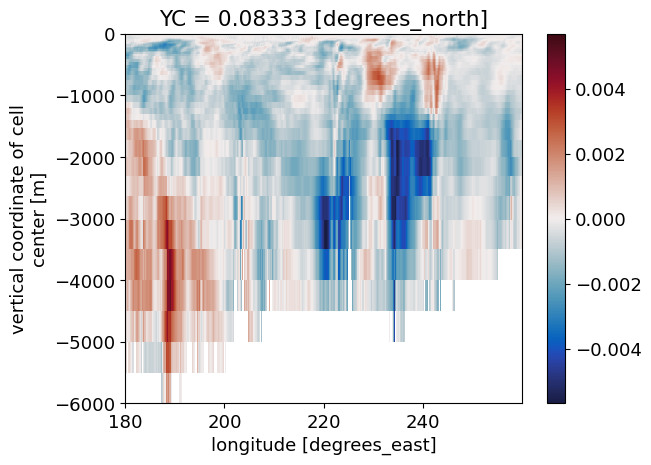

In [16]:
Fz.sel(YC=0.0, method='nearest').plot(cmap=cmo.balance)

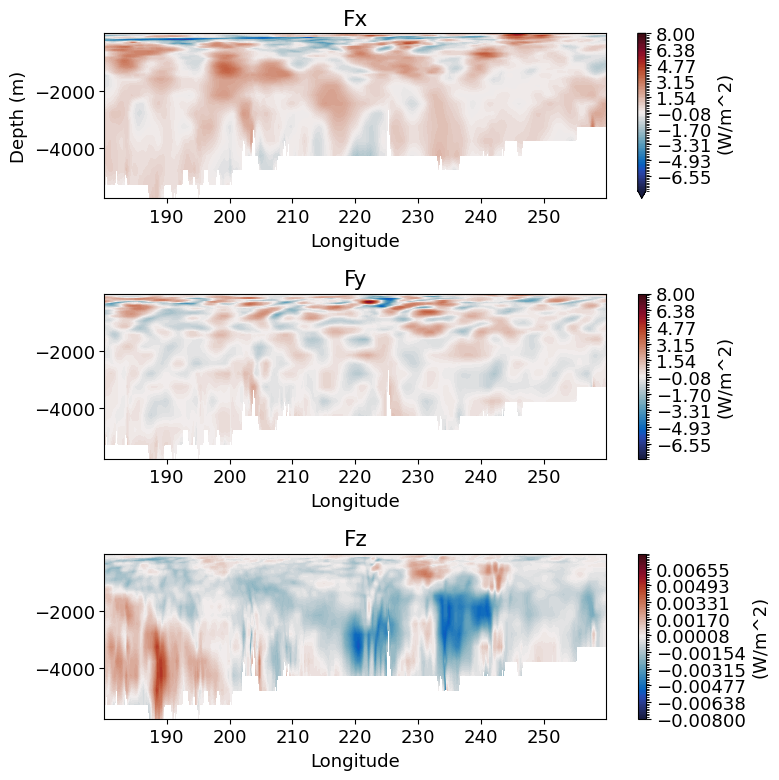

In [22]:
fig, ax = plt.subplots(figsize=(8, 8),nrows=3,sharey=True)
levels = np.linspace(-8,8,100)
Fx.sel(YC=0.0, method='nearest').plot.contourf(ax=ax[0],levels=levels, cmap=cmo.balance, cbar_kwargs={'label':'(W/m^2)'})
ax[0].set_ylabel('Depth (m)')
ax[0].set_xlabel('Longitude')
ax[0].set_title('Fx')

Fy.sel(YC=0.0, method='nearest').plot.contourf(ax=ax[1],levels=levels, cmap=cmo.balance, cbar_kwargs={'label':'(W/m^2)'})
ax[1].set_ylabel('')
ax[1].set_xlabel('Longitude')
ax[1].set_title('Fy')

levels = np.linspace(-0.008,0.008,100)
Fz.sel(YC=0.0, method='nearest').plot.contourf(ax=ax[2],levels=levels, cmap=cmo.balance, cbar_kwargs={'label':'(W/m^2)'})
ax[2].set_ylabel('')
ax[2].set_xlabel('Longitude')
ax[2].set_title('Fz')

plt.tight_layout()
fig.savefig(foldername + 'energy_flux_depth_lon_TAO.png', dpi=300)

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 5.13 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


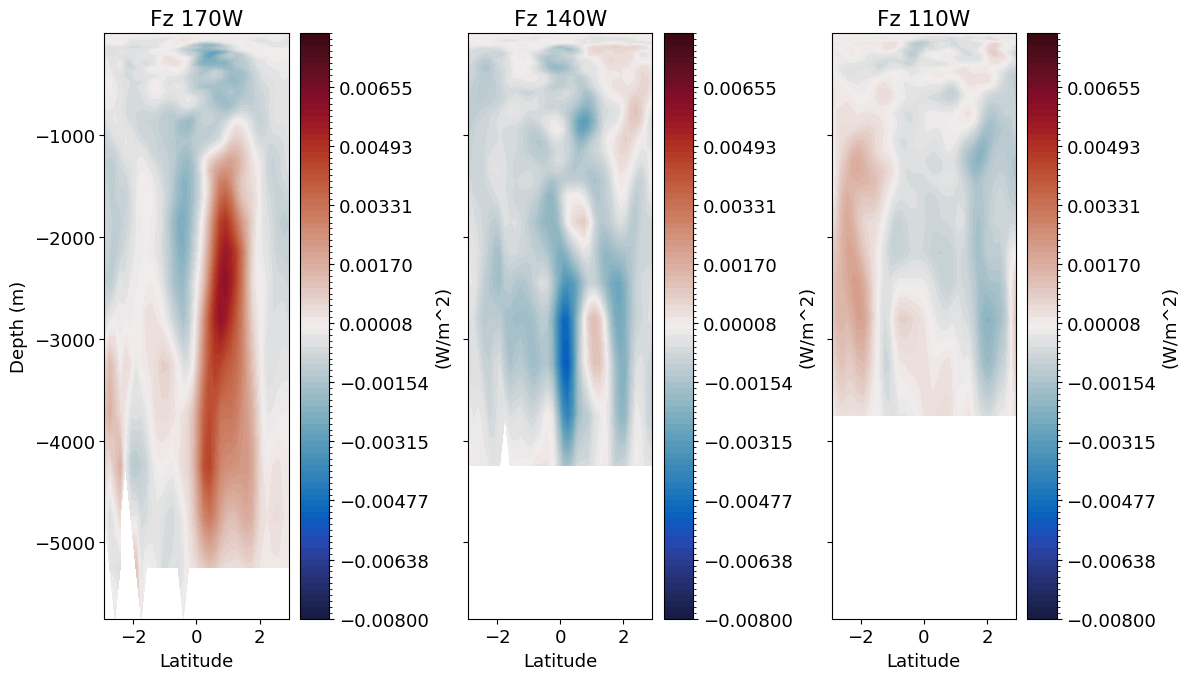

In [26]:
fig, ax = plt.subplots(figsize=(12, 7),ncols=3,sharey=True)
levels = np.linspace(-0.008,0.008,100)
Fz.sel(XC=190.0, method='nearest').plot.contourf(ax=ax[0],x='YC', levels=levels, cmap=cmo.balance, cbar_kwargs={'label':'(W/m^2)'})
ax[0].set_ylabel('Depth (m)')
ax[0].set_xlabel('Latitude')
ax[0].set_title('Fz 170W')

Fz.sel(XC=220.0, method='nearest').plot.contourf(ax=ax[1],x='YC', levels=levels, cmap=cmo.balance, cbar_kwargs={'label':'(W/m^2)'})
ax[1].set_ylabel('')
ax[1].set_xlabel('Latitude')
ax[1].set_title('Fz 140W')

levels = np.linspace(-0.008,0.008,100)
Fz.sel(XC=250.0, method='nearest').plot.contourf(ax=ax[2],x='YC', levels=levels, cmap=cmo.balance, cbar_kwargs={'label':'(W/m^2)'})
ax[2].set_ylabel('')
ax[2].set_xlabel('Latitude')
ax[2].set_title('Fz 110W')

plt.tight_layout()
fig.savefig(foldername + 'vertical_energy_flux_depth_lat_TAO.png', dpi=300)

### Repeat without TAO assimilation

In [40]:
import numpy as np
import gsw  # TEOS-10, optional if using MITgcm EOS

# Constants
rho0 = 1035.0  # reference density
g = 9.81       # gravity

p = gsw.p_from_z(ds_tpose_noTAO.Z, 0.0) # convert these to pressure at the equator
SA = gsw.SA_from_SP(ds_tpose_noTAO.SALT.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)), p, ds_tpose_noTAO.SALT.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)).XC, 0.0)
CT = gsw.CT_from_pt(SA, ds_tpose_noTAO.THETA.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)))
rho = gsw.rho(SA, CT, p)

temp = ds_tpose_noTAO.THETA.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)).copy(deep=True)
temp.values = rho
rho = temp

rho = rho.where(ds_tpose_noTAO.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)).maskC)

# 2. pressure anomaly
rho_anomaly = (rho - rho.mean(dim='time'))  # shape (z,y,x)

# 3. Integrate hydrostatic pressure from surface down
# multiply b by drF first (broadcasting)
rho_dz = rho_anomaly * ds_tpose_noTAO.drF * ds_tpose_noTAO.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)).hFacC  # shape (time, z)

# cumulative sum along vertical axis
p_prime = g*rho_dz.cumsum(dim='Z')

uvel = detrend(ds_tpose_noTAO.UVEL.sel(XG=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)),axis=0)
uvel_anom = uvel - uvel.mean(axis=0)
vvel = detrend(ds_tpose_noTAO.VVEL.sel(XC=slice(lon_min,lon_max),YG=slice(lat_min,lat_max)),axis=0)
vvel_anom = vvel - vvel.mean(axis=0)
wvel = detrend(ds_tpose_noTAO.WVEL.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)),axis=0)
wvel_anom = wvel - wvel.mean(axis=0)

p_prime_bandpass = sosfiltfilt(sos, detrend(p_prime,axis=0), axis=0)
uvel_prime = sosfiltfilt(sos, uvel_anom, axis=0)
vvel_prime = sosfiltfilt(sos, vvel_anom, axis=0)
wvel_prime = sosfiltfilt(sos, wvel_anom, axis=0)

temp = rho.copy(deep=True)
temp.data = p_prime_bandpass
p_prime_bandpass = temp

temp = ds_tpose_noTAO.UVEL.sel(XG=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)).copy(deep=True)
temp.data = uvel_prime
uvel_prime = temp

temp = ds_tpose_noTAO.VVEL.sel(XC=slice(lon_min,lon_max),YG=slice(lat_min,lat_max)).copy(deep=True)
temp.data = vvel_prime
vvel_prime = temp

temp = ds_tpose_noTAO.WVEL.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)).copy(deep=True)
temp.data = wvel_prime
wvel_prime = temp

p_prime = p_prime_bandpass.where(ds_tpose_noTAO.maskC.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)))

In [41]:
ds_crop = ds_tpose_noTAO.sel(YC=slice(lat_min, lat_max), XC=slice(lon_min, lon_max),YG=slice(lat_min, lat_max), XG=slice(lon_min, lon_max))
grid_crop = xgcm.Grid(ds_crop, periodic=False)  # usually False for subset
w_prime_interp = grid_crop.interp(wvel_prime, 'Z', boundary='fill')
u_prime_interp = grid_crop.interp(uvel_prime, 'X', boundary='fill')
v_prime_interp = grid_crop.interp(vvel_prime, 'Y', boundary='fill')

In [42]:
Fx_noTAO = (np.abs(p_prime * u_prime_interp)).mean(dim="time")
Fy_noTAO = (np.abs(p_prime * v_prime_interp)).mean(dim="time")
Fz_noTAO = (np.abs(p_prime * w_prime_interp)).mean(dim="time")

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 5.13 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 5.15 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size

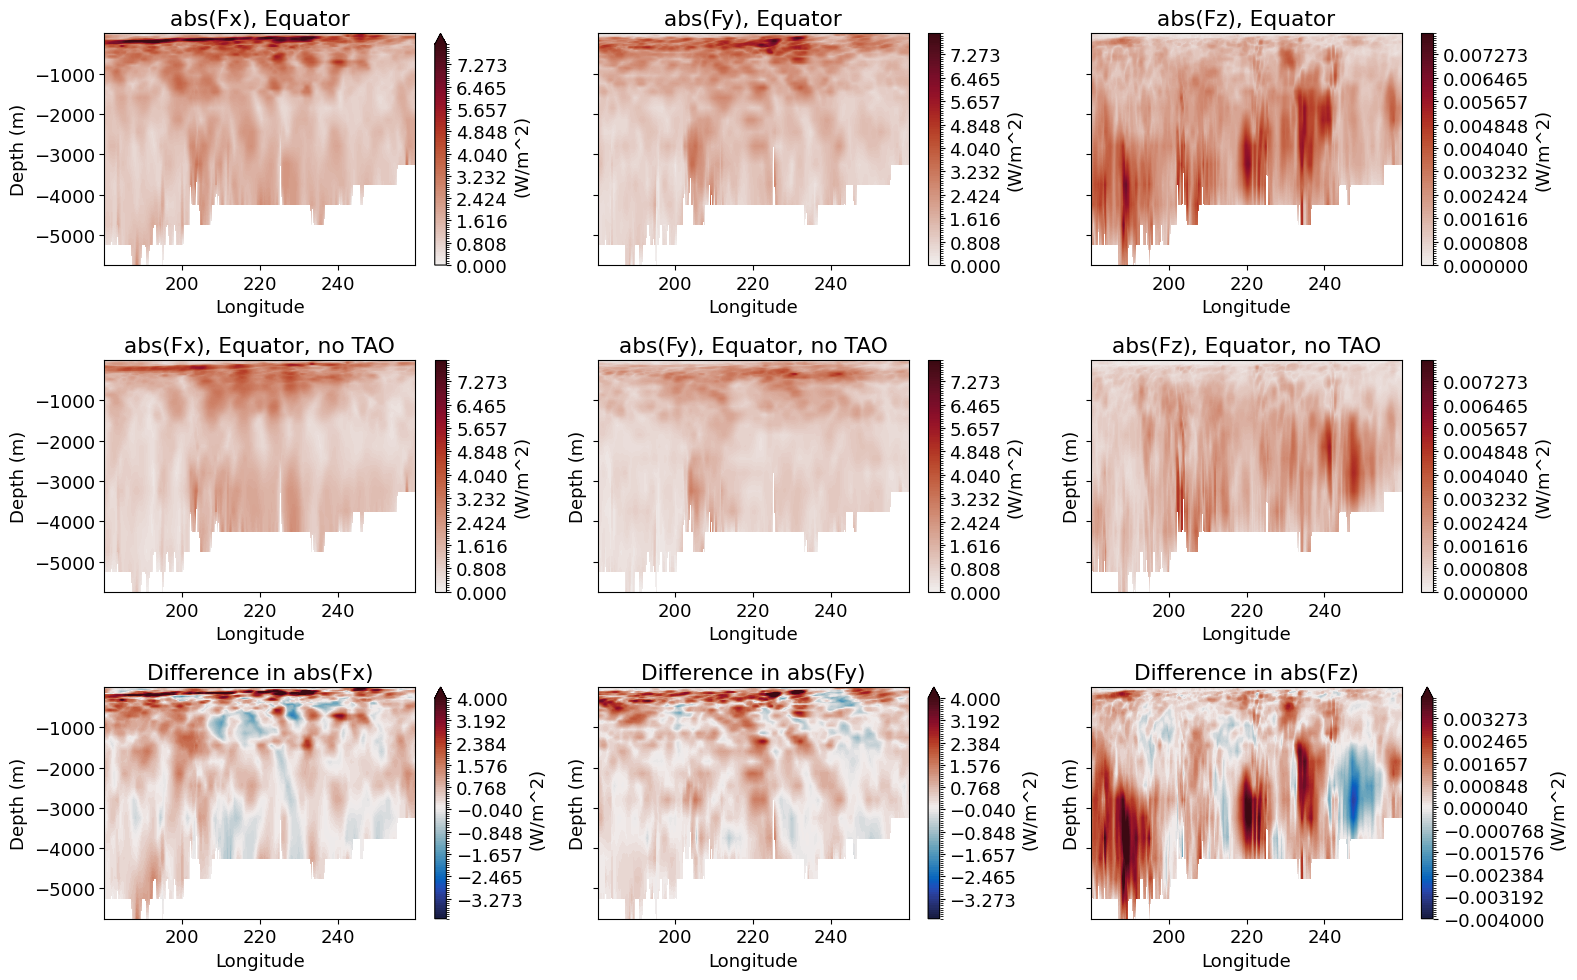

2026-03-04 14:54:37,946 - tornado.application - ERROR - Exception in callback functools.partial(<function TCPServer._handle_connection.<locals>.<lambda> at 0x7f4d4e9427a0>, <Task finished name='Task-1162092' coro=<BaseTCPListener._handle_stream() done, defined at /home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/comm/tcp.py:655> exception=MemoryError((7002586286238287176,), dtype('uint8'))>)
Traceback (most recent call last):
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/tornado/tcpserver.py", line 387, in <lambda>
    gen.convert_yielded(future), lambda f: f.result()
                                           ^^^^^^^^^^
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/comm/tcp.py", line 667, in _handle_stream
    await self.o

In [43]:
fig, ax = plt.subplots(figsize=(16, 10),nrows=3,ncols=3,sharey=True)
levels = np.linspace(0,8,100)
Fx.sel(YC=0.0, method='nearest').plot.contourf(ax=ax[0,0],levels=levels, cmap=cmo.amp, cbar_kwargs={'label':'(W/m^2)'})
ax[0,0].set_ylabel('Depth (m)')
ax[0,0].set_xlabel('Longitude')
ax[0,0].set_title('abs(Fx), Equator')

Fx_noTAO.sel(YC=0.0, method='nearest').plot.contourf(ax=ax[1,0],levels=levels, cmap=cmo.amp, cbar_kwargs={'label':'(W/m^2)'})
ax[1,0].set_ylabel('Depth (m)')
ax[1,0].set_xlabel('Longitude')
ax[1,0].set_title('abs(Fx), Equator, no TAO')

levels = np.linspace(-4,4,100)
(Fx-Fx_noTAO).sel(YC=0.0, method='nearest').plot.contourf(ax=ax[2,0],levels=levels, cmap=cmo.balance, cbar_kwargs={'label':'(W/m^2)'})
ax[2,0].set_ylabel('Depth (m)')
ax[2,0].set_xlabel('Longitude')
ax[2,0].set_title('Difference in abs(Fx)')

levels = np.linspace(0,8,100)
Fy.sel(YC=0.0, method='nearest').plot.contourf(ax=ax[0,1],levels=levels, cmap=cmo.amp, cbar_kwargs={'label':'(W/m^2)'})
ax[0,1].set_ylabel('')
ax[0,1].set_xlabel('Longitude')
ax[0,1].set_title('abs(Fy), Equator')

Fy_noTAO.sel(YC=0.0, method='nearest').plot.contourf(ax=ax[1,1],levels=levels, cmap=cmo.amp, cbar_kwargs={'label':'(W/m^2)'})
ax[1,1].set_ylabel('Depth (m)')
ax[1,1].set_xlabel('Longitude')
ax[1,1].set_title('abs(Fy), Equator, no TAO')

levels = np.linspace(-4,4,100)
(Fy-Fy_noTAO).sel(YC=0.0, method='nearest').plot.contourf(ax=ax[2,1],levels=levels, cmap=cmo.balance, cbar_kwargs={'label':'(W/m^2)'})
ax[2,1].set_ylabel('Depth (m)')
ax[2,1].set_xlabel('Longitude')
ax[2,1].set_title('Difference in abs(Fy)')

levels = np.linspace(0,0.008,100)
Fz.sel(YC=0.0, method='nearest').plot.contourf(ax=ax[0,2],levels=levels, cmap=cmo.amp, cbar_kwargs={'label':'(W/m^2)'})
ax[0,2].set_ylabel('')
ax[0,2].set_xlabel('Longitude')
ax[0,2].set_title('abs(Fz), Equator')

Fz_noTAO.sel(YC=0.0, method='nearest').plot.contourf(ax=ax[1,2],levels=levels, cmap=cmo.amp, cbar_kwargs={'label':'(W/m^2)'})
ax[1,2].set_ylabel('Depth (m)')
ax[1,2].set_xlabel('Longitude')
ax[1,2].set_title('abs(Fz), Equator, no TAO')

levels = np.linspace(-0.004,0.004,100)
(Fz-Fz_noTAO).sel(YC=0.0, method='nearest').plot.contourf(ax=ax[2,2],levels=levels, cmap=cmo.balance, cbar_kwargs={'label':'(W/m^2)'})
ax[2,2].set_ylabel('Depth (m)')
ax[2,2].set_xlabel('Longitude')
ax[2,2].set_title('Difference in abs(Fz)')

plt.tight_layout()
fig.savefig(foldername + 'energy_flux_depth_lon_compare_magnitude.png', dpi=300)

In [44]:
client.shutdown()
cluster.close()
client.close()